In [1]:
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error
from tensorflow import truediv

In [2]:
from keras.datasets import cifar10
(x_data, y_data),(tt_x, tt_y) = cifar10.load_data()

In [3]:
e_x_data = x_data / 255.0
e_tt_x = tt_x / 255.0

In [4]:
tr_x, val_x, tr_y, val_y = train_test_split(e_x_data, y_data, train_size=0.8, stratify=y_data)

In [5]:
tr_y.shape

(40000, 1)

In [6]:
from keras.layers import Flatten
from keras.regularizers import l2

m = Sequential()

m.add(Input(shape=tr_x.shape[1:]))

m.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
m.add(BatchNormalization())
m.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
m.add(BatchNormalization())
m.add(MaxPooling2D((2, 2)))
m.add(Dropout(0.4))

m.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
m.add(BatchNormalization())
m.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
m.add(BatchNormalization())
m.add(MaxPooling2D((2, 2)))
m.add(Dropout(0.4))

m.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
m.add(BatchNormalization())
m.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
m.add(BatchNormalization())
m.add(MaxPooling2D((2, 2)))
m.add(Dropout(0.4))

m.add(Flatten())
m.add(Dense(512, activation='relu'))
m.add(BatchNormalization())
m.add(Dropout(0.5))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,253,834 (12.41 MB)

 Trainable params: 3,251,018 (12.40 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [7]:
total_steps = (len(tr_x) // 64) * 200

In [8]:

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)
datagen.fit(tr_x)

In [9]:
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

In [10]:
m.compile(loss='sparse_categorical_crossentropy', optimizer=sgd, metrics=['acc'])

In [11]:
es = EarlyStopping(patience=10, verbose=1, mode='auto', restore_best_weights=True)
ck = ModelCheckpoint('best_m.keras', save_best_only=True, verbose=1)

In [12]:
hy = m.fit(datagen.flow(tr_x, tr_y, batch_size=64),
           validation_data=(val_x, val_y),
           epochs=200,
           steps_per_epoch=len(tr_x) // 64,
           callbacks=[es, ck])

Epoch 1/200


/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - acc: 0.2456 - loss: 2.4801
Epoch 1: val_loss improved from inf to 1.85069, saving model to best_m.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 102ms/step - acc: 0.2457 - loss: 2.4794 - val_acc: 0.3617 - val_loss: 1.8507
Epoch 2/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - acc: 0.3509 - loss: 2.0491
Epoch 2: val_loss did not improve from 1.85069
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - acc: 0.3509 - loss: 2.0490 - val_acc: 0.3081 - val_loss: 2.2075
Epoch 3/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - acc: 0.3878 - loss: 1.8862
Epoch 3: val_loss improved from 1.85069 to 1.82882, saving model to best_m.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - acc: 0.3878 - loss: 1.8862 - val_acc: 0.3936 - val_loss: 1.8288
Epoch 4/200
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - acc: 0.4260 - loss: 1.6950
Epoch 4: val_loss improved from 1.82882 to 1.61414, saving model to best_m.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - acc: 0.4260 - loss

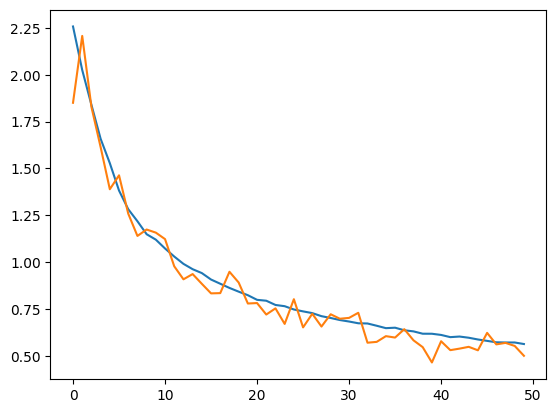

In [13]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

In [14]:
from keras.models import load_model
l_m=load_model('best_m.keras')
print(l_m.evaluate(tr_x,tr_y))
print(l_m.evaluate(e_tt_x,tt_y))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.8647 - loss: 0.3894
[0.3926176130771637, 0.8647500276565552]
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8332 - loss: 0.4951
[0.4930654764175415, 0.8342000246047974]
